In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
from gensim import corpora
from gensim.models import LdaModel,TfidfModel,LsiModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.metrics import accuracy_score,classification_report

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SmAsHeR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SmAsHeR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SmAsHeR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
en_stopwords = stopwords.words('english')
lemmatizer = WordNetLemmatizer()
vader_sentiment = SentimentIntensityAnalyzer()
countvec = CountVectorizer()

In [3]:
data = pd.read_csv('datasets/fake_news_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


In [4]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [5]:
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = '#00bfbf'

Text(0.5, 1.0, 'Count of Article Classification')

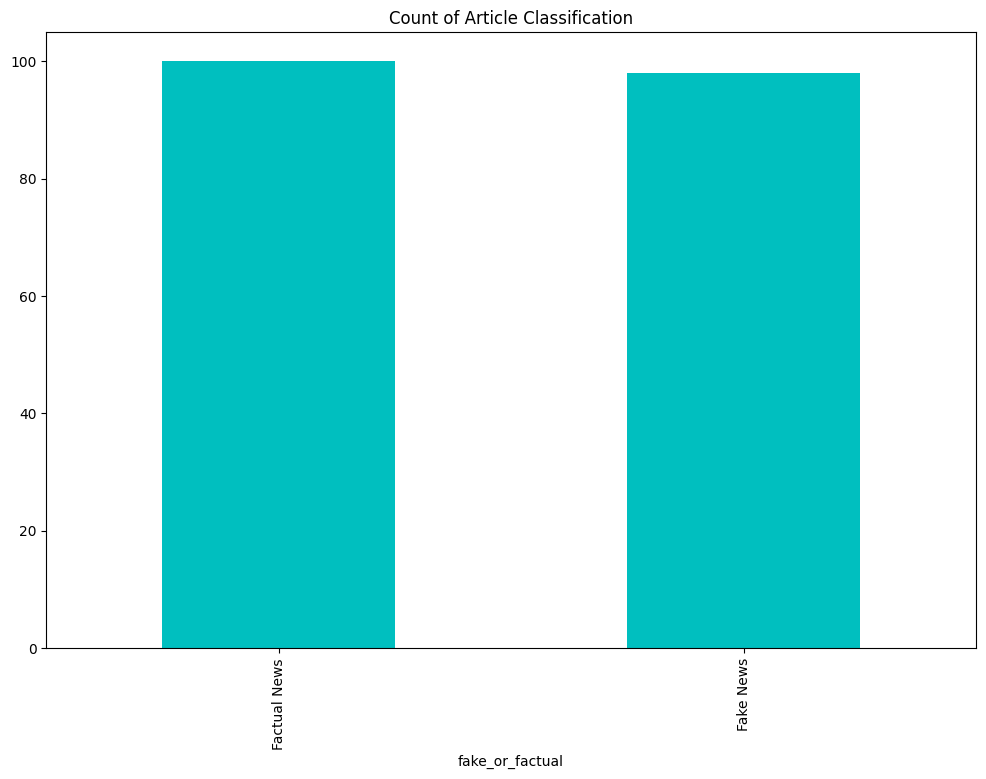

In [6]:
data['fake_or_factual'].value_counts().plot(kind = 'bar', color = default_plot_colour)
plt.title('Count of Article Classification')

POS tagging

In [7]:
nlp = spacy.load('en_core_web_sm')

In [8]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
fact_news = data[data['fake_or_factual'] == 'Factual News']
# fact_news.head()

In [9]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [10]:
fake_tagsdf = pd.DataFrame([ (token.text, token.ent_type_, token.pos_ ) for spacydoc in fake_spacydocs for token in spacydoc ], columns = ['token', 'ner_tag', 'pos_tag'])
fake_tagsdf.head()
    

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [11]:
fact_tagsdf = pd.DataFrame([(token.text, token.ent_type_, token.pos_ ) for spacydoc in fact_spacydocs for token in spacydoc ], columns = ['token', 'ner_tag', 'pos_tag'])
fact_tagsdf.head()

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT


In [12]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name = 'counts').sort_values(by = 'counts', ascending = False)
pos_counts_fake.head(10)

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [13]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name = 'counts').sort_values(by = 'counts', ascending = False)
pos_counts_fact.head(10)

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [14]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending =  False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [15]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending = False).head(10)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [16]:
pos_counts_fake[pos_counts_fake.pos_tag == 'NOUN'][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [17]:
pos_counts_fact[pos_counts_fact.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


Named Entities

In [18]:
top_entities_fake = fake_tagsdf[fake_tagsdf.ner_tag != ""].groupby(['token', 'ner_tag']).size().reset_index(name = 'counts').sort_values(by = 'counts', ascending = False)
top_entities_fake.head(10)

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


In [19]:
top_entities_fact = fact_tagsdf[fact_tagsdf.ner_tag != ""].groupby(['token', 'ner_tag']).size().reset_index(name = 'counts').sort_values(by = 'counts', ascending = False)
top_entities_fact.head(10)

,token,ner_tag,counts
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
882,House,ORG,67
1997,year,DATE,63
1646,United,GPE,59
1965,the,GPE,59
1254,Obama,PERSON,55


In [20]:
ner_palette = {
    'ORG' : sns.color_palette("Set2").as_hex()[0],
    'GPE' : sns.color_palette("Set2").as_hex()[1],
    'NORP' : sns.color_palette("Set2").as_hex()[2],
    'PERSON' : sns.color_palette("Set2").as_hex()[3],
    'DATE' : sns.color_palette("Set2").as_hex()[4],
    'CARDINAL' : sns.color_palette("Set2").as_hex()[5],
    'PERCENT' : sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Named Entities in Fake News')]

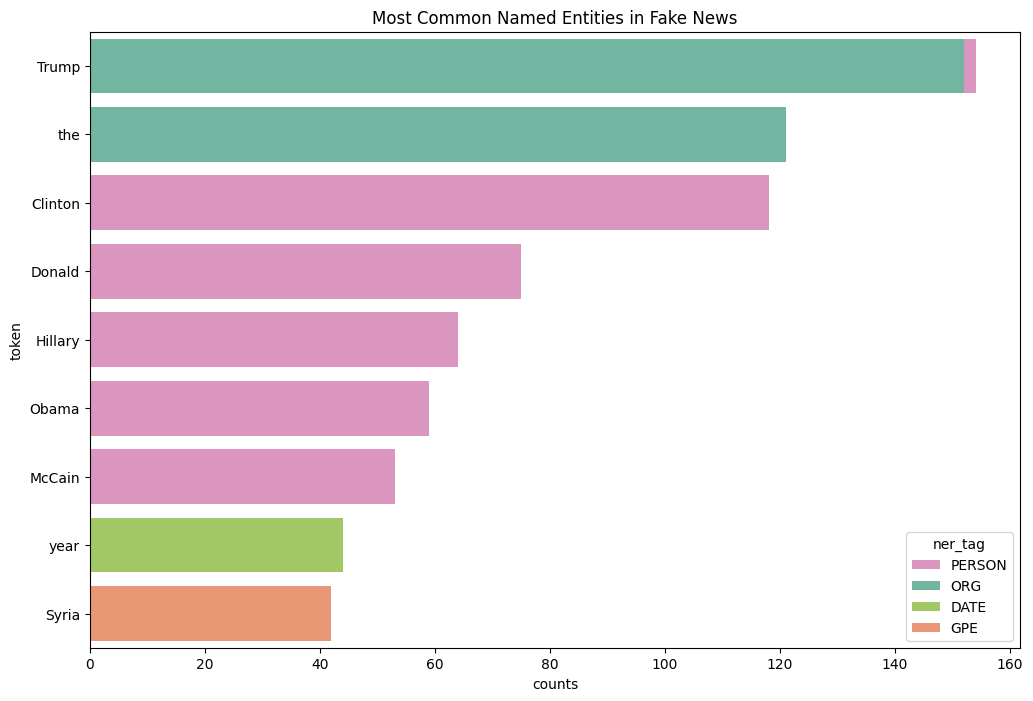

In [21]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False
).set(title = "Most Common Named Entities in Fake News")

[Text(0.5, 1.0, 'Most Common Named Entities in Factual News')]

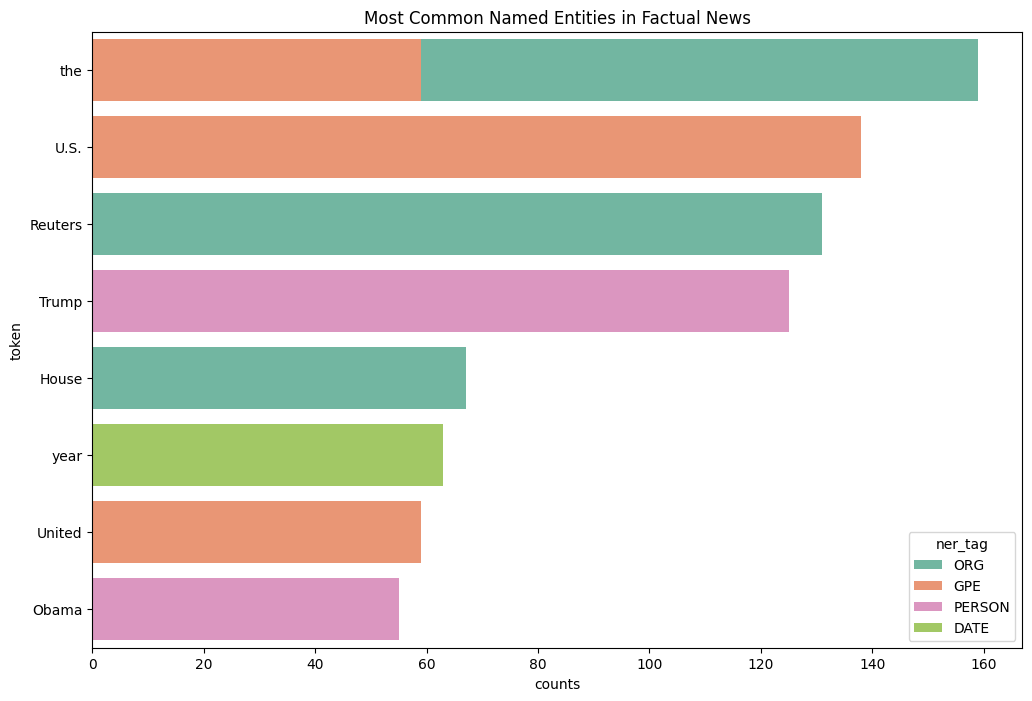

In [22]:
sns.barplot(
    x = 'counts',
    y = 'token',
    data = top_entities_fact[:10],
    hue = 'ner_tag',
    palette = ner_palette,
    orient = 'h',
    dodge = False
).set(title = "Most Common Named Entities in Factual News")

Text Pre-Processing

In [23]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [24]:
data['text_clean'] = data['text'].apply(lambda x : re.sub( r"^[^-]*-\s", "", x.lower() ))
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,there are two small problems with your analogy...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried in trump s bonkers interview with new y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"women make up over 50 percent of this country,..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,u.s. defense secretary jim mattis said on mond...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland s political parties are rapid...


In [25]:
data['text_clean'] = data['text_clean'].apply(lambda x : re.sub( r"[^\w\s]", "", x ))
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,there are two small problems with your analogy...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried in trump s bonkers interview with new y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make up over 50 percent of this country ...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said on monday...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland s political parties are rapid...


In [26]:
data['text_clean'] = data['text_clean'].apply( lambda x : ' '.join([word for word in x.split() if word not in en_stopwords]))
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,two small problems analogy susan jesus muslim ...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried trump bonkers interview new york times ...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make 50 percent country grossly underrep...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said monday ru...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland political parties rapidly run...


In [27]:
data['text_clean'] = data['text_clean'].apply(lambda x : word_tokenize(x))
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problems, analogy, susan, jesus, ..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[women, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[us, defense, secretary, jim, mattis, said, mo..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, parties, rapidl..."


In [28]:
data['text_clean'] = data['text_clean'].apply(lambda x : [lemmatizer.lemmatize(word) for word in x])
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [29]:
# tokens_clean = sum(data['text_clean'],[])
# unigrams = pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts().reset_index()
# print(unigrams[:10])

tokens_clean = [token for tokens in data['text_clean'] for token in tokens]
unigrams = pd.Series(tokens_clean).value_counts().reset_index(name = 'counts').rename(columns = {'index' : 'token'})
print(unigrams[:10])

        token  counts
0        said     580
1       trump     580
2           u     277
3       state     275
4   president     259
5       would     226
6         one     160
7     clinton     141
8        year     139
9  republican     137


C:\Users\SmAsHeR\AppData\Local\Temp\ipykernel_34016\4077175542.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

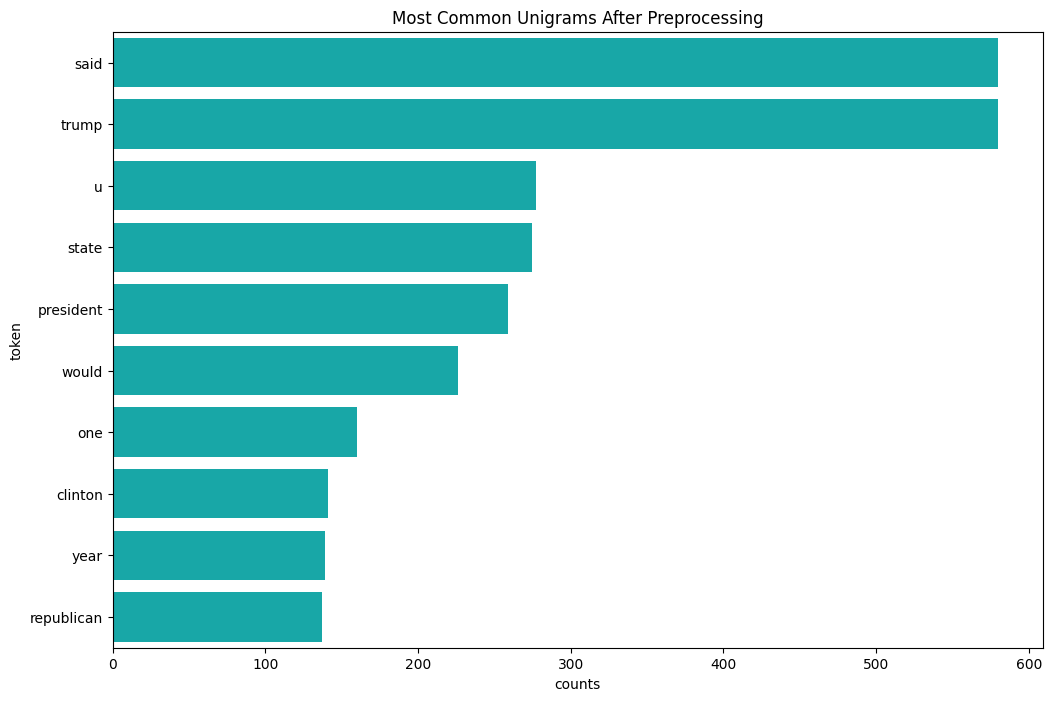

In [30]:
sns.barplot(
    x='counts',
    y='token',
    data = unigrams[:10],
    orient = 'h',
    palette = [default_plot_colour],
    hue = 'token',
    legend = False
).set( title = 'Most Common Unigrams After Preprocessing')

In [31]:
tokens_clean = [ token for tokens in data['text_clean'] for token in tokens]
bigrams = pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts().reset_index(name = 'counts').rename(columns = {'index' : 'token'})
bigrams['token'] = bigrams['token'].apply(lambda x : ' '.join(x))
bigrams[:10]

,token,counts
0,donald trump,113
1,united state,84
2,white house,74
3,president donald,47
4,hillary clinton,39
5,new york,33
6,supreme court,30
7,image via,29
8,official said,26
9,trump administration,26


C:\Users\SmAsHeR\AppData\Local\Temp\ipykernel_34016\419549729.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most Common Bigrams After Preprocessing')]

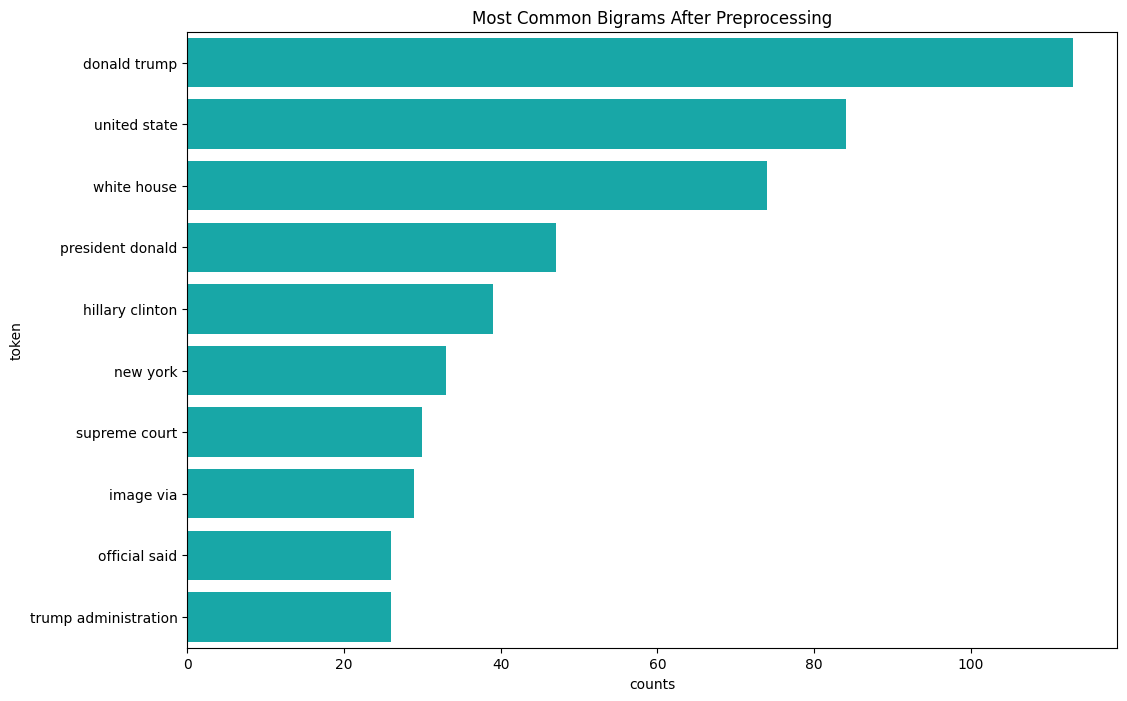

In [32]:
sns.barplot(
    x='counts',
    y='token',
    data = bigrams[:10],
    hue = 'token',
    palette = [default_plot_colour],
    orient = 'h',
    legend = False
).set( title = "Most Common Bigrams After Preprocessing")

Sentiment Analysis

In [33]:
data['vader_sentiment_score'] = data['text'].apply(lambda x : vader_sentiment.polarity_scores(x)['compound'])
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [34]:
bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels = names)
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


<Axes: xlabel='vader_sentiment_label'>

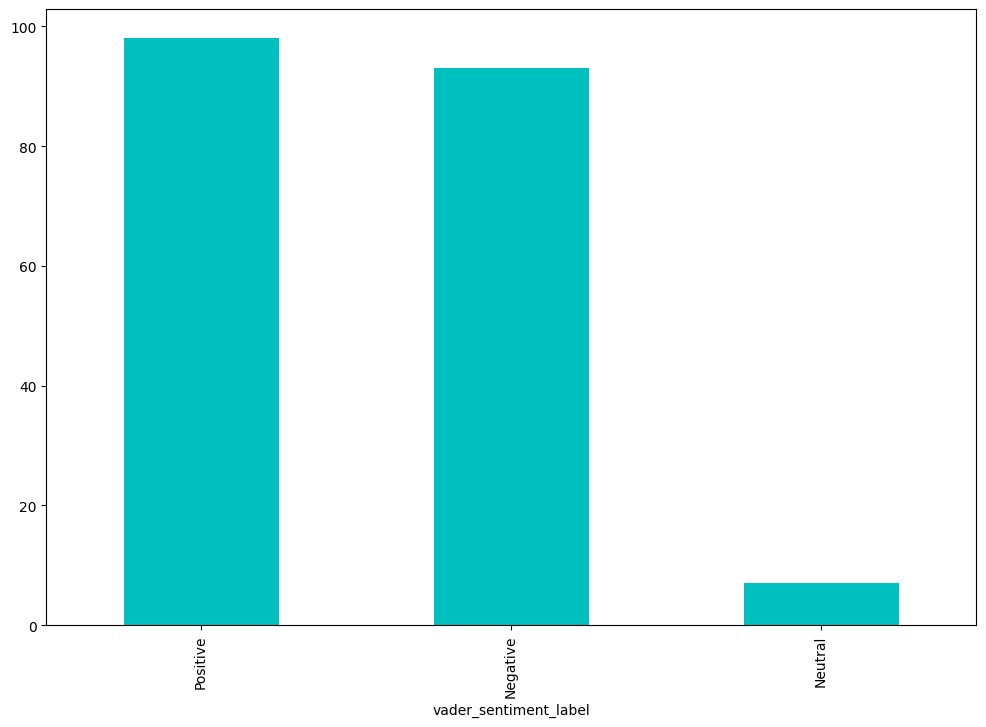

In [35]:
data['vader_sentiment_label'].value_counts().plot( kind = 'bar', color = default_plot_colour)

C:\Users\SmAsHeR\AppData\Local\Temp\ipykernel_34016\664185163.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

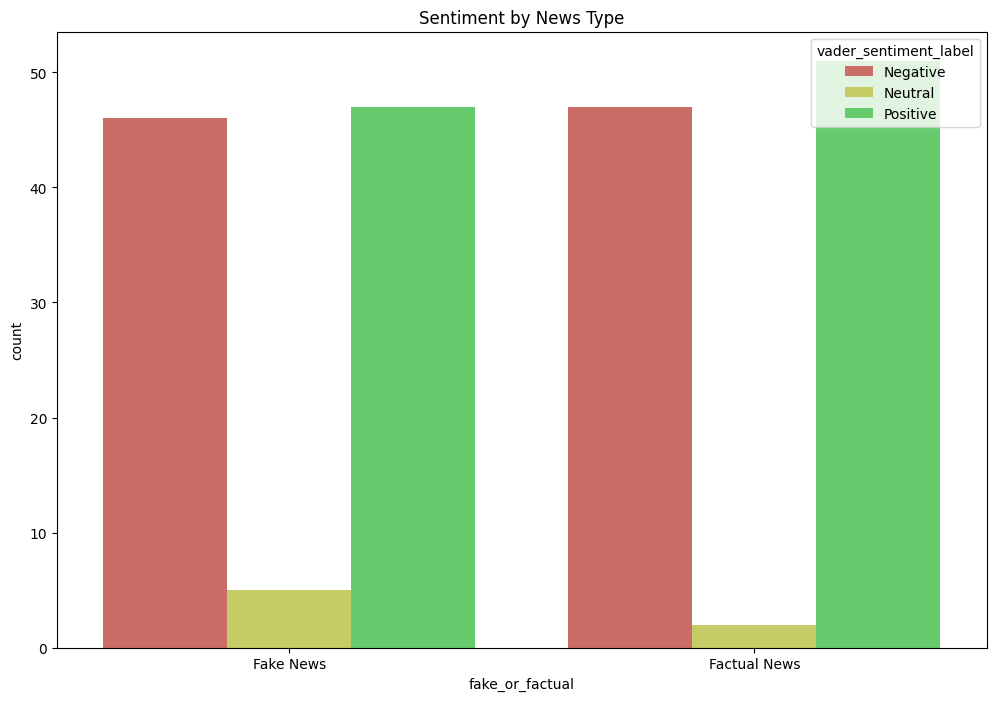

In [36]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette('hls'),
    data = data
).set( title = "Sentiment by News Type")

Topic Modelling

In [37]:
fake_news_text = data[data['fake_or_factual'] == 'Fake News']
fake_news_text.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
5,Maxine Waters Makes Teens Chant ‘Impeach 45′ a...,Shame on Teen Vogue! Maxine Waters was a guest...,"Dec 10, 2017",Fake News,"[shame, teen, vogue, maxine, water, guest, tee...",-0.6781,Negative
6,Jay Carney Let It Slip That He Knows Who Obam...,Former White House Press Secretary in the Obam...,"February 10, 2016",Fake News,"[former, white, house, press, secretary, obama...",0.9970,Positive


In [38]:
dictionary_fake = corpora.Dictionary(fake_news_text['text_clean'])

In [39]:
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text ['text_clean']]

In [40]:
coherence_values = []
min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = LdaModel(corpus = doc_term_fake, id2word = dictionary_fake, num_topics = num_topics_i)
    coherence_model = CoherenceModel(model = model, texts = fake_news_text['text_clean'], dictionary = dictionary_fake, coherence = 'c_v')
    coherence_values.append(coherence_model.get_coherence())
coherence_values

[0.24752232741611624,
 0.2610822225653589,
 0.2528392070975798,
 0.25988021402317885,
 0.2706430180935088,
 0.2562826323251245,
 0.2599409256138142,
 0.26983223161709446,
 0.2798597786877197,
 0.27888198300981615]

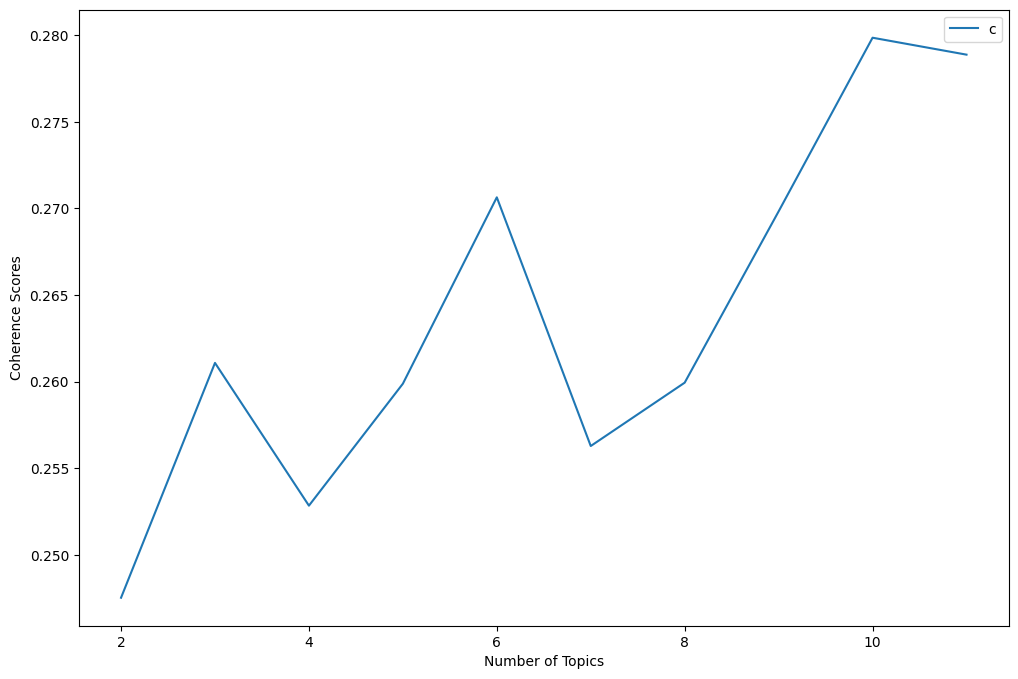

In [41]:
plt.plot(range(min_topics, max_topics + 1), coherence_values)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Scores')
plt.legend(('coherence_values'), loc = 'best')
plt.show()

In [42]:
num_topics_f = 10
lda_model = LdaModel(corpus = doc_term_fake, id2word = dictionary_fake, num_topics = num_topics_f)
lda_model.print_topics(num_topics = num_topics_f, num_words = 10)

[(0,
  '0.017*"trump" + 0.007*"president" + 0.007*"said" + 0.004*"one" + 0.004*"woman" + 0.004*"republican" + 0.004*"would" + 0.004*"donald" + 0.003*"state" + 0.003*"penny"'),
 (1,
  '0.009*"trump" + 0.005*"u" + 0.004*"clinton" + 0.004*"said" + 0.004*"would" + 0.003*"one" + 0.003*"people" + 0.003*"mccain" + 0.003*"law" + 0.003*"woman"'),
 (2,
  '0.008*"trump" + 0.004*"said" + 0.004*"one" + 0.004*"would" + 0.003*"year" + 0.003*"employee" + 0.003*"time" + 0.003*"state" + 0.003*"clinton" + 0.003*"woman"'),
 (3,
  '0.011*"trump" + 0.006*"president" + 0.004*"would" + 0.004*"said" + 0.004*"one" + 0.004*"state" + 0.003*"donald" + 0.003*"know" + 0.003*"school" + 0.003*"hillary"'),
 (4,
  '0.013*"trump" + 0.007*"clinton" + 0.005*"state" + 0.005*"would" + 0.004*"said" + 0.004*"president" + 0.004*"woman" + 0.003*"time" + 0.003*"obama" + 0.003*"donald"'),
 (5,
  '0.009*"trump" + 0.005*"state" + 0.004*"president" + 0.004*"clinton" + 0.004*"said" + 0.003*"people" + 0.003*"mccain" + 0.003*"u" + 0.003

In [43]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus = doc_term_matrix, normalize = True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf


In [44]:
def get_coherence_scores(corpus, dictionary, texts, min_topics, max_topics):
    coherence_values = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus = corpus, id2word = dictionary, num_topics = num_topics_i)
        coherence_model = CoherenceModel(model = model, texts = texts, dictionary = dictionary, coherence = 'c_v')
        coherence_values.append(coherence_model.get_coherence())
    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel('Number of Topics')
    plt.ylabel('Coherence Scores')
    plt.legend(('coherence_values'), loc = 'best')
    plt.show()
    

In [45]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

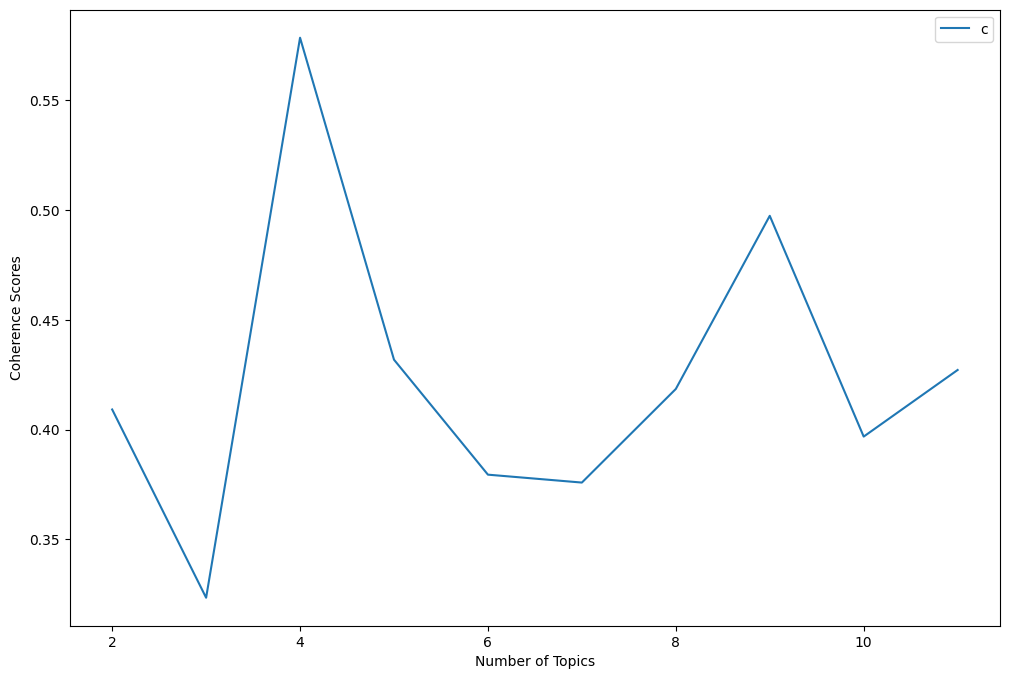

In [46]:
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text['text_clean'], 2, 11)

In [47]:
lsa_model = LsiModel(corpus = corpus_tfidf_fake, id2word = dictionary_fake, num_topics = 4)
lsa_model.print_topics()

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.077*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '-0.325*"boiler" + -0.284*"acr" + -0.244*"room" + -0.240*"pm" + -0.186*"broadcast" + -0.180*"radio" + -0.142*"tune" + -0.142*"animal" + -0.134*"jay" + -0.132*"episode"'),
 (2,
  '-0.623*"flynn" + -0.182*"immunity" + -0.122*"nana" + -0.116*"mr" + -0.110*"30" + -0.108*"march" + -0.102*"russian" + -0.100*"source" + 0.095*"school" + -0.092*"adviser"'),
 (3,
  '0.217*"clinton" + -0.186*"school" + -0.176*"student" + 0.141*"hillary" + -0.121*"county" + -0.121*"flynn" + 0.110*"sander" + 0.098*"debate" + 0.097*"woman" + 0.091*"nominee"')]

Creating our Classification Model

In [48]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


In [49]:
data['text_clean'] = data['text_clean'].apply(lambda x : ' '.join(x))
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,two small problem analogy susan jesus muslim j...,-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried trump bonkers interview new york time r...,-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,woman make 50 percent country grossly underrep...,0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,u defense secretary jim mattis said monday rus...,-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland political party rapidly runni...,0.8590,Positive


In [50]:
X = data['text_clean']
Y = data['fake_or_factual']

countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns = countvec.get_feature_names_out())
bag_of_words

,01,03,05,08441,10,100,1000,10000,1000000000000000,1002,...,zimbabwean,zimdars,zimmerman,zina,zionism,zoe,zone,zoom,zouka,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
194,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size = 0.3, random_state = 7)

In [57]:
lr = LogisticRegression(random_state = 0).fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
accuracy_score(y_pred_lr, y_test)

0.7833333333333333

In [58]:
print(classification_report(y_test, y_pred_lr, zero_division = 0))

              precision    recall  f1-score   support

Factual News       0.79      0.76      0.77        29
   Fake News       0.78      0.81      0.79        31

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



In [149]:
svm = SGDClassifier().fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_pred_svm, y_test)

0.85

In [150]:
print(classification_report(y_test, y_pred_svm, zero_division = 0))

              precision    recall  f1-score   support

Factual News       0.92      0.76      0.83        29
   Fake News       0.81      0.94      0.87        31

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

